In [9]:
-- Explore the data in the table
SELECT *
FROM 'safeboda_trips.csv'

,trip_ref,date,time,pickup,dropoff,driver_name,trip_type,service_type,distance_km,duration_min,price_per_minute_ugx,price_per_km_ugx,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,payment_method,order_total_ugx
0,657e9542-4cfa-4297-9f93-5724b27e0e37,2026-03-26 00:00:00+00:00,18:48:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Luyirika Waswa husein,Bike,Ride,9,32,30,320,500,2000,950,2978,1550,447,6424,6500,Mobile_money,6669
1,db7dae87-939a-4dc6-9ef2-e09572a5cc01,2026-03-26 00:00:00+00:00,11:14:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Paul Ayebare,Bike,Ride,11,20,30,320,500,2000,604,3376,672,7,5158,5000,Mobile_money,5130
2,e4344ace-7b62-4417-a66b-86d21fa4c8f7,2026-03-25 00:00:00+00:00,18:39:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Charles Kintu,Bike,Ride,9,24,30,320,500,2000,731,3005,1483,451,6169,6000,Mobile_money,6156
3,cee84c96-01ce-471a-afee-4be211eaf16c,2026-03-25 00:00:00+00:00,09:32:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Joshua Mwambu,Bike,Ride,11,22,30,320,500,2000,672,3376,910,7,5464,5500,Mobile_money,5643
4,b11049df-440d-4115-9d06-140ae6184bd1,2026-03-23 00:00:00+00:00,18:51:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Ashiraf Ssenfuka,Bike,Ride,9,29,30,320,500,2000,882,2964,1521,445,6312,6500,Mobile_money,6669
5,1ae8aa56-99ba-4e68-a7f3-819a6022e1b7,2026-03-23 00:00:00+00:00,11:11:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Mutaawe Muzamiru,Bike,Ride,11,19,30,320,500,2000,583,3376,669,7,5134,5000,Mobile_money,5130
6,f1786aaf-a679-47d6-91b0-b8d64b974f1e,2026-03-22 00:00:00+00:00,10:24:00,Dawson Kyaliwajjala Gas Station,Watoto Church Bweyogerere,Julius Katekoko,Bike,Ride,7,14,30,320,500,2000,410,2179,463,327,3879,4000,Mobile_money,4104
7,e805d35d-9584-44ba-9eb8-c2676ac3bcf3,2026-03-19 00:00:00+00:00,18:38:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Degeya Ali,Bike,Ride,9,28,30,320,500,2000,843,2972,1510,446,6271,6500,Mobile_money,6669
8,831f33ec-8944-4e16-b2ff-a98d8d0fd41c,2026-03-19 00:00:00+00:00,11:02:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Charles Katwaka,Bike,Ride,11,21,30,320,500,2000,634,3376,676,7,5193,5000,Mobile_money,5130
9,2a1a00ff-2f84-4e8b-97dc-18dfeba8540e,2026-03-18 00:00:00+00:00,18:52:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Canwat Geofrey,Bike,Ride,9,32,30,320,500,2000,947,2971,1546,446,6410,6500,Mobile_money,6669


Context: I very often use bodas to get around and so i spend quite a significant amount on them every week hence this is something I ought care about. I personally use the Safeboda app and i came to realise that leaving aside distance covered because I very often just go to university, I realised I tend to be priced differently. I suspect its because of time of day and day of week and this project is aimed at digging into this somewhat mystery.
Analysis Question: “For my own SafeBoda trips, after controlling for distance, how do prices vary by time of day and day of week?”

Analysis subquestions(first draft):
What does my trip data look like overall?
What does the distribution of price( maybe per km) look like (maybe over time)?
How does peak hour price vary by time of day? (update)
How does price per km vary by time of day?
How does price per km vary by day of week?
How does price per km vary by day of week and time of day?
Are there specific ‘peak’ windows where my prices are noticeably higher?
Are there obvious outliers or special events?
Do these patterns support or contradict my suspicion?

In [ ]:
# claude csv update code

What does my trip data look like overall?

In [10]:
df.head()

,trip_ref,date,time,pickup,dropoff,driver_name,trip_type,service_type,distance_km,duration_min,price_per_minute_ugx,price_per_km_ugx,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,payment_method,order_total_ugx
0,657e9542-4cfa-4297-9f93-5724b27e0e37,2026-03-26 00:00:00+00:00,18:48:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Luyirika Waswa husein,Bike,Ride,9,32,30,320,500,2000,950,2978,1550,447,6424,6500,Mobile_money,6669
1,db7dae87-939a-4dc6-9ef2-e09572a5cc01,2026-03-26 00:00:00+00:00,11:14:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Paul Ayebare,Bike,Ride,11,20,30,320,500,2000,604,3376,672,7,5158,5000,Mobile_money,5130
2,e4344ace-7b62-4417-a66b-86d21fa4c8f7,2026-03-25 00:00:00+00:00,18:39:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Charles Kintu,Bike,Ride,9,24,30,320,500,2000,731,3005,1483,451,6169,6000,Mobile_money,6156
3,cee84c96-01ce-471a-afee-4be211eaf16c,2026-03-25 00:00:00+00:00,09:32:00,Dawson Kyaliwajjala Gas Station,ISBAT University,Joshua Mwambu,Bike,Ride,11,22,30,320,500,2000,672,3376,910,7,5464,5500,Mobile_money,5643
4,b11049df-440d-4115-9d06-140ae6184bd1,2026-03-23 00:00:00+00:00,18:51:00,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Ashiraf Ssenfuka,Bike,Ride,9,29,30,320,500,2000,882,2964,1521,445,6312,6500,Mobile_money,6669


In [6]:
df.columns

Index(['trip_ref', 'date', 'time', 'pickup', 'dropoff', 'driver_name',
       'trip_type', 'service_type', 'distance_km', 'duration_min',
       'price_per_minute_ugx', 'price_per_km_ugx', 'base_fare_ugx',
       'min_fare_ugx', 'duration_cost_ugx', 'distance_cost_ugx',
       'peak_hour_price_ugx', 'long_ride_charge_ugx', 'subtotal_ugx',
       'ride_cost_ugx', 'payment_method', 'order_total_ugx'],
      dtype='object')

Univariate analysis:
Now I am interested specifically in the column "peak_hour_price_ugx". Let's look more into it

In [11]:
all_rows = df.loc[:, 'peak_hour_price_ugx']
all_rows

0     1550
1      672
2     1483
3      910
4     1521
5      669
6      463
7     1510
8      676
9     1546
10     900
11    1506
12     687
13    1056
14    1442
15     661
16    1534
17     675
18    1563
19     922
20    1553
21     678
22    1078
23    1487
24     668
25    1528
26     689
27    1535
28     914
29    1571
30     684
31    1063
32    1488
33     724
34    1523
35     687
36    1493
37     906
38    1500
39     699
40    1041
41    1476
42     673
43    1527
44     688
45    1522
46    1625
47    1242
48    1754
49     804
Name: peak_hour_price_ugx, dtype: int64

Interesting, the charges aren't that constant so there is variation and hence distribution which I should look more into...

<Axes: ylabel='Frequency'>

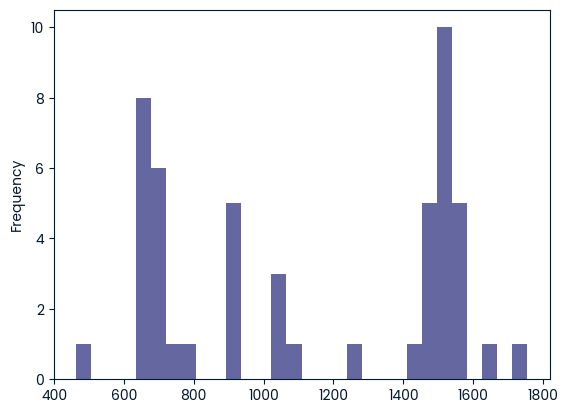

In [12]:
df["peak_hour_price_ugx"].plot.hist(bins=30)

So we have multimodal distribution! This points to a pattern in the pricing which is something we need to investigate more. Let's see if it how the distribution is for each day of the week...

<Axes: >

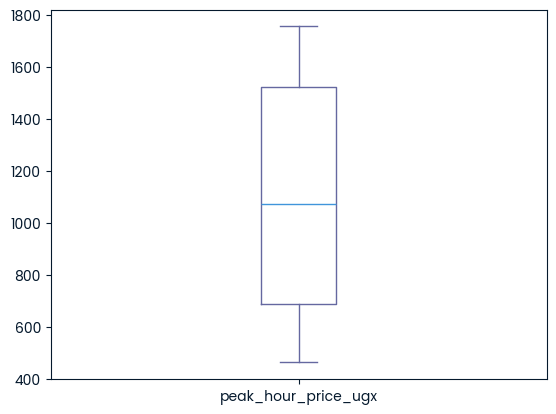

In [13]:
df["peak_hour_price_ugx"].plot.box()

### groupby day and see boxplots for peak hour price for each

In [ ]:
df['day'] = df['date'].dt.day()